In [1]:
#!/usr/bin/env python

# Written by CFM @ ESTEC on Jan, 28th 2016
# AIM: from the new Baraffe tracks, create an interpolated version and put it in a sav file as the other evolutionary tracks I have

import numpy as np
from scipy.io.idl import readsav
import sys
import pylab as pl


path = '/Users/cmanara/work/utilities/evolutionary_tracks/BHAC15/'


In [2]:
%matplotlib inline

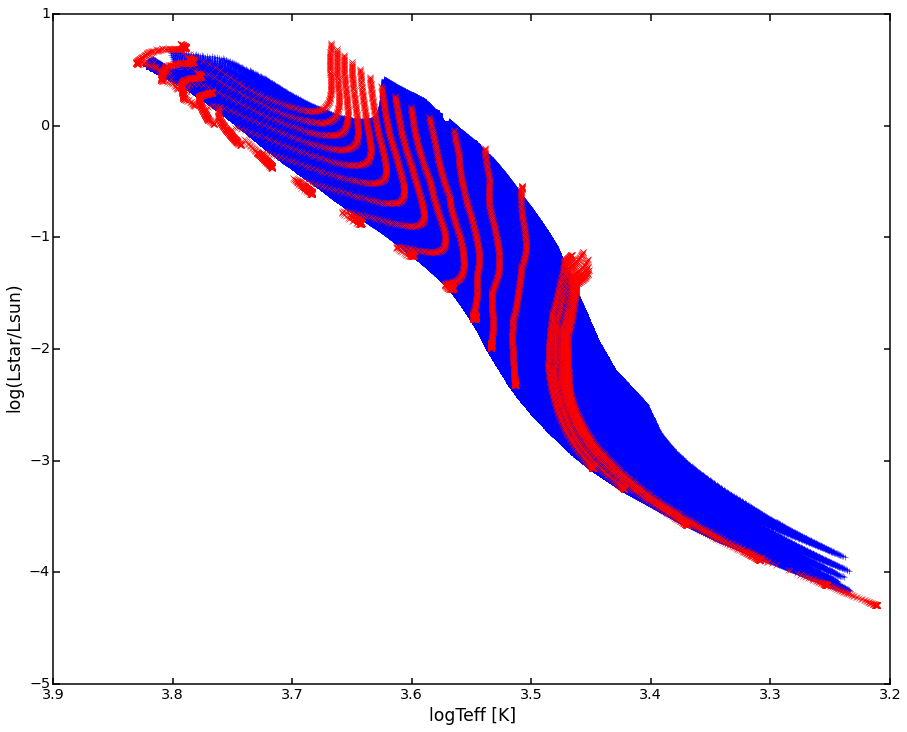

In [3]:
# check how dense the tracks are

# read the new ones
data_b15 = np.genfromtxt(path+'BHAC15.dat',names=True, skip_header=45,invalid_raise=False)
# read the old B98
s = readsav('/Users/cmanara/work/utilities/evolutionary_tracks/tracks_bcah98_dense.sav')
l,t,m,a = s['l'],s['t'],s['m'],s['a']
s.clear()

# plot the two
pl.figure(figsize=(15,12))
pl.plot(t,l,'b+')
pl.plot(np.log10(data_b15['Teff']),data_b15['logl'],'rx')
pl.xlabel('logTeff [K]')
pl.ylabel('log(Lstar/Lsun)')
ax = pl.gca()
ax.invert_xaxis()
pl.show()
#pl.close()

# ok, the new one is very sparse. I should interpolate it to make it denser


In [4]:
# what are the Mstar in the two sets of models?
print np.unique(data_b15['Mstar'])
print np.unique(m)

[ 0.07   0.072  0.075  0.08   0.09   0.1    0.2    0.3    0.4    0.5    0.6
  0.7    0.8    0.9    1.     1.1    1.2    1.3    1.4  ]
[ 0.02        0.02025     0.0205     ...,  1.39499998  1.39750004
  1.39999998]


In [5]:
# the new ones do not go to the same lower mass, but have the same higher Mstar
# what about ages?
print np.min(np.unique(10.**data_b15['logage']/1e6)), np.max(np.unique(10.**data_b15['logage']/1e6))
print len(np.unique(10.**data_b15['logage']/1e6))
print np.min(np.unique(10.**a/1e6)),np.max(np.unique(10.**a/1e6))
print len(np.unique(10.**a/1e6))

0.488652359343 10000.0
3094
1.0 1000.0
601


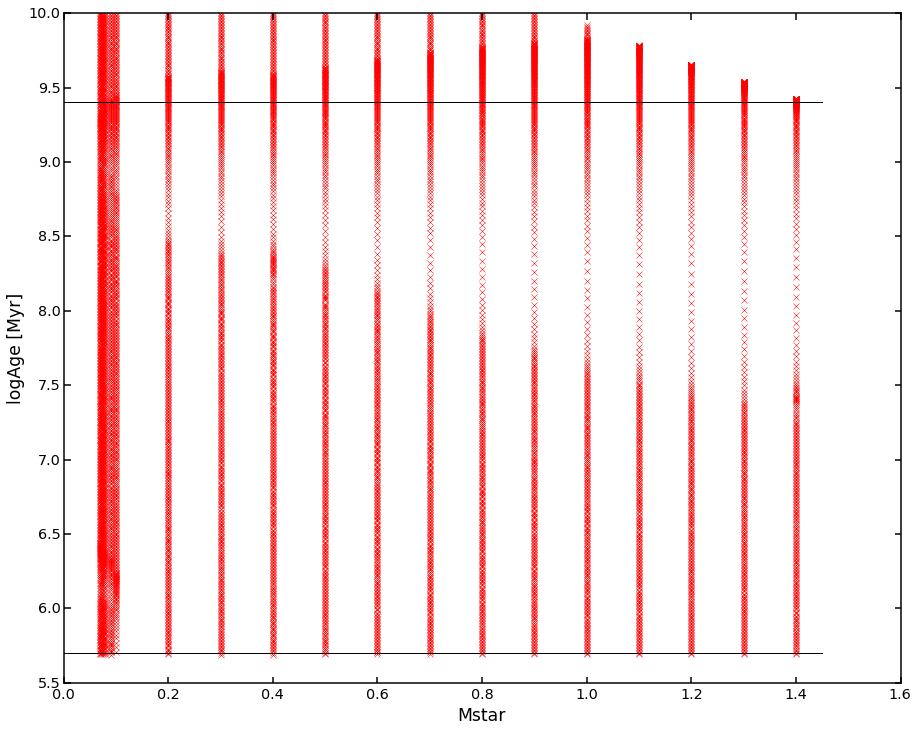

In [6]:
# ages start earlier and finish later and there are more unique points
pl.figure(figsize=(15,12))
pl.plot(data_b15['Mstar'],data_b15['logage'],'rx')
pl.plot([0,1.45],[5.7,5.7],'k')
pl.plot([0,1.45],[9.4,9.4],'k')
pl.xlabel('Mstar')
pl.ylabel('logAge [Myr]')
pl.show()

In [7]:
# but at all Mstar the tracks are initiated at the same logage
# I'll proceed this way: first interpolate each Mstar on the same logage scale (from 5.7 to 9.4)
# then I will interpolate at each age on more Mstar

In [8]:
# create the arrays where to store the variables
loga_new, m_new, logl_new, t_new = np.array([]),np.array([]),np.array([]),np.array([])


In [57]:
for i in xrange(len(np.unique(data_b15['Mstar']))):
    print len(data_b15['logage'][(data_b15['Mstar']==np.unique(data_b15['Mstar'])[i])&(data_b15['logage']<=9.4)])

371
372
371
370
369
366
349
343
347
338
325
312
301
291
282
276
269
264
301


In [58]:
# INTERPOLATE ON LOGAGE
# define a dense logage sequence - there are at most 372 points between 5.7 and 9.4 in the original models
logage_steps = np.linspace(5.7,9.4,num=400)

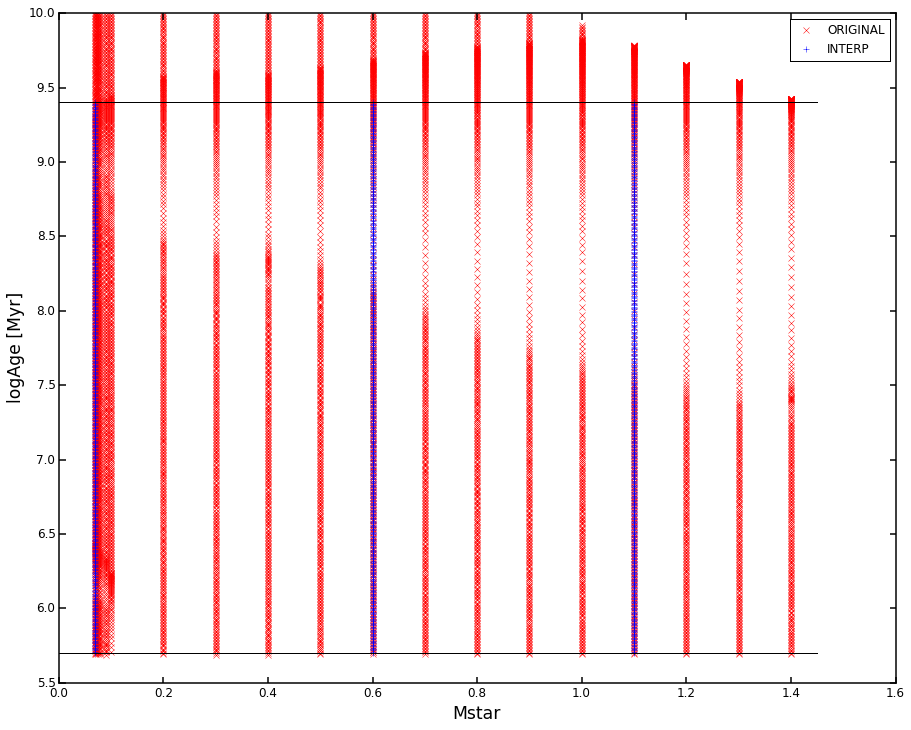

In [59]:
pl.figure(figsize=(15,12))
pl.plot(data_b15['Mstar'],data_b15['logage'],'rx',label='ORIGINAL')
pl.plot(np.repeat(np.unique(data_b15['Mstar'])[0],len(logage_steps)),logage_steps,'b+',label='INTERP')
pl.plot(np.repeat(np.unique(data_b15['Mstar'])[10],len(logage_steps)),logage_steps,'b+')
pl.plot(np.repeat(np.unique(data_b15['Mstar'])[15],len(logage_steps)),logage_steps,'b+')
pl.plot([0,1.45],[5.7,5.7],'k')
pl.plot([0,1.45],[9.4,9.4],'k')
pl.legend(loc='upper right')
pl.xlabel('Mstar')
pl.ylabel('logAge [Myr]')
pl.show()

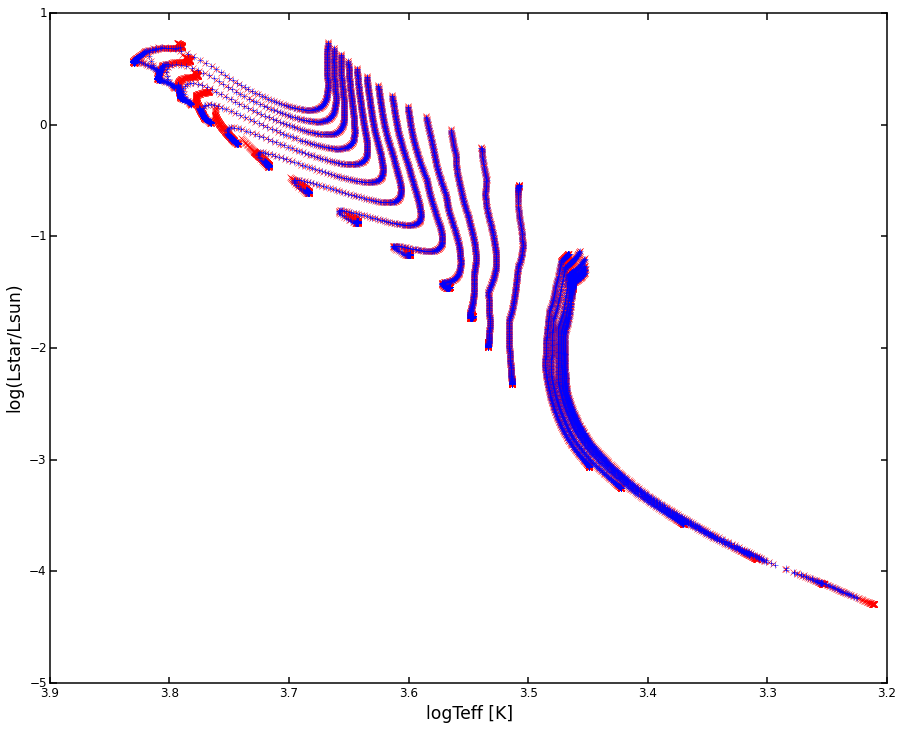

7600 7600 7600 7600


In [60]:
# for each unique Mstar, interpolate the track on the same logage

pl.figure(figsize=(15,12))
pl.plot(np.log10(data_b15['Teff']),data_b15['logl'],'rx')
pl.xlabel('logTeff [K]')
pl.ylabel('log(Lstar/Lsun)')
ax = pl.gca()
ax.invert_xaxis()

for i in xrange(len(np.unique(data_b15['Mstar']))):
    # interpolate logL and Teff
    logl_temp = np.interp(logage_steps, data_b15['logage'][data_b15['Mstar']==np.unique(data_b15['Mstar'])[i]], data_b15['logl'][data_b15['Mstar']==np.unique(data_b15['Mstar'])[i]])
    teff_temp = np.interp(logage_steps, data_b15['logage'][data_b15['Mstar']==np.unique(data_b15['Mstar'])[i]], data_b15['Teff'][data_b15['Mstar']==np.unique(data_b15['Mstar'])[i]])           
    # plot to check
    pl.plot(np.log10(teff_temp),logl_temp,'b+')
    # append logL, Teff, logage, mstar to the arrays with the interpolated isochrones
    loga_new = np.append(loga_new,logage_steps)
    m_new = np.append(m_new,np.repeat(np.unique(data_b15['Mstar'])[i],len(logage_steps)))
    logl_new = np.append(logl_new,logl_temp)
    t_new = np.append(t_new,teff_temp)

pl.show()

print len(loga_new),len(m_new), len(logl_new),len(t_new)

In [61]:
# INTERPOLATE ON Mstar
# define a dense mstar sequence 
mstar_steps_init = np.linspace(np.min(np.unique(data_b15['Mstar'])),np.max(np.unique(data_b15['Mstar'])),num=400)

In [62]:
# but exclude those masses already included in the interpolated grid
mstar_steps = np.array([])
for i in xrange(len(mstar_steps_init)):
#    if mstar_steps_init[i] not in np.unique(data_b15['Mstar']):
    if np.all(np.abs(mstar_steps_init[i] - np.unique(data_b15['Mstar'])) > 1e-12) :
        mstar_steps = np.append(mstar_steps,mstar_steps_init[i])
    else:
        pass
#        print mstar_steps_init[i]
#print len(mstar_steps)
#print np.unique(data_b15['Mstar'])
#print mstar_steps

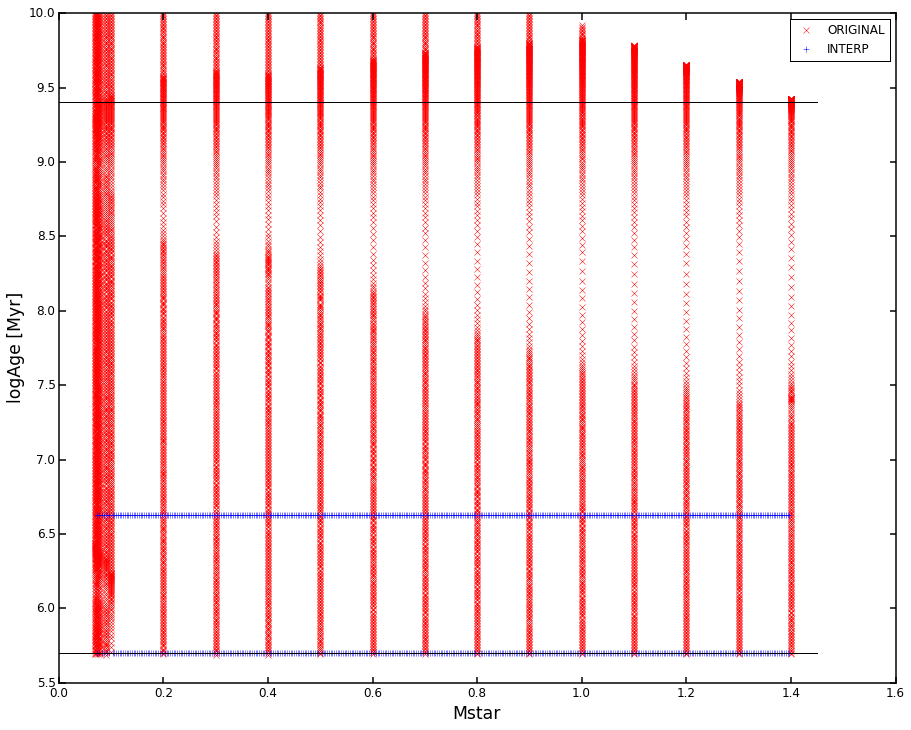

In [63]:
pl.figure(figsize=(15,12))
pl.plot(data_b15['Mstar'],data_b15['logage'],'rx',label='ORIGINAL')
pl.plot(mstar_steps,np.repeat(logage_steps[0],len(mstar_steps)),'b+',label='INTERP')
pl.plot(mstar_steps,np.repeat(logage_steps[100],len(mstar_steps)),'b+')
pl.plot([0,1.45],[5.7,5.7],'k')
pl.plot([0,1.45],[9.4,9.4],'k')
pl.legend(loc='upper right')
pl.xlabel('Mstar')
pl.ylabel('logAge [Myr]')
pl.show()

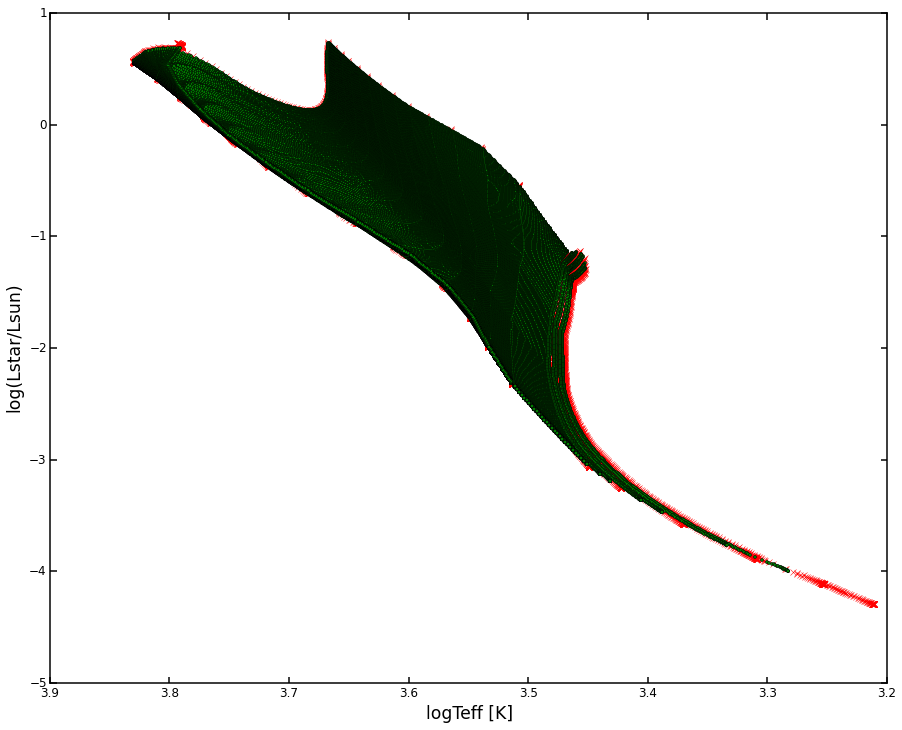

160800 160800 160800 160800


In [64]:
# now for each logage step, interpolate on the new Mstar step

pl.figure(figsize=(15,12))
pl.plot(np.log10(data_b15['Teff']),data_b15['logl'],'rx',label='ORIGINAL')
pl.xlabel('logTeff [K]')
pl.ylabel('log(Lstar/Lsun)')
ax = pl.gca()
ax.invert_xaxis()

for i in xrange(len(logage_steps)):
    # interpolate logL and Teff
    logl_temp = np.interp(mstar_steps, m_new[loga_new == logage_steps[i]], logl_new[loga_new == logage_steps[i]])
    teff_temp = np.interp(mstar_steps, m_new[loga_new == logage_steps[i]], t_new[loga_new == logage_steps[i]])           
    # plot to check
    pl.plot(np.log10(teff_temp),logl_temp,'go',ms=3)
    # append logL, Teff, logage, mstar to the arrays with the interpolated isochrones
    loga_new = np.append(loga_new,np.repeat(logage_steps[i],len(mstar_steps)))
    m_new = np.append(m_new,mstar_steps)
    logl_new = np.append(logl_new,logl_temp)
    t_new = np.append(t_new,teff_temp)

pl.show()

print len(loga_new),len(m_new), len(logl_new),len(t_new)

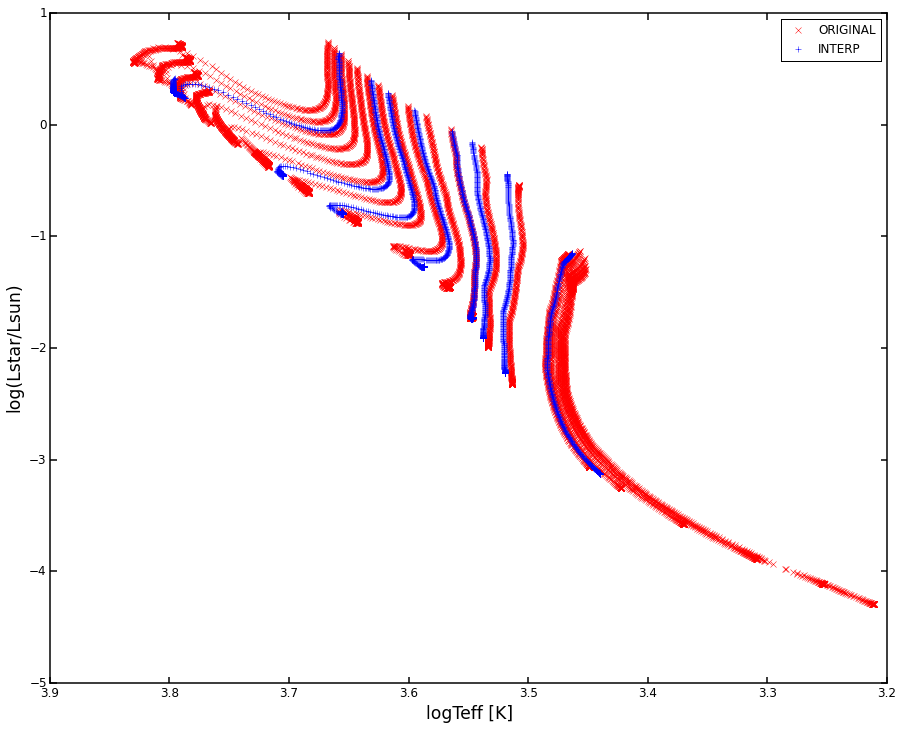

In [65]:
# check by plotting some tracks
pl.figure(figsize=(15,12))
pl.plot(np.log10(data_b15['Teff']),data_b15['logl'],'rx',label='ORIGINAL')
pl.xlabel('logTeff [K]')
pl.ylabel('log(Lstar/Lsun)')
ax = pl.gca()
ax.invert_xaxis()
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[10]]),logl_new[m_new==np.unique(m_new)[10]],'b+',label='INTERP')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[50]]),logl_new[m_new==np.unique(m_new)[50]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[80]]),logl_new[m_new==np.unique(m_new)[80]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[100]]),logl_new[m_new==np.unique(m_new)[100]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[150]]),logl_new[m_new==np.unique(m_new)[150]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[200]]),logl_new[m_new==np.unique(m_new)[200]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[240]]),logl_new[m_new==np.unique(m_new)[240]],'b+')
pl.plot(np.log10(t_new[m_new==np.unique(m_new)[350]]),logl_new[m_new==np.unique(m_new)[350]],'b+')

pl.legend(loc='upper right')
#for i in xrange(len(np.unique(m_new))):
 #   pl.plot(np.log10(t_new[m_new==np.unique(m_new)[i]]),logl_new[m_new==np.unique(m_new)[i]],'b+')
#  i+=100
pl.show()

In [66]:
# save everything in an enormous file (I need to read it in IDL)
np.savetxt(path+'tracks_bhac15_dense.txt',np.transpose([logl_new,t_new,loga_new,m_new]),header='logL Teff logAge Mstar')


In [ ]:
##### 2016-06-10 : 